In [1]:
import sys
sys.path.append('/Users/juanrios/Documents/Maestria/master_thesis')
from syntethic_data.syntethic_causal_data import SyntheticCausalSystem
from causal_discovery.causal_discovery import LiNGAMWithFCI, PCWithFCI, compare_with_ground_truth
from predictive_models.predictive_models import LGBMRegressor, NeuralNetRegressor, train_predictive_models
from explainability_models import ShapleyExplainer, ShapleyFromScratch
from utils.utils import visualize_causal_graph, visualize_comparison
import pandas as pd

/Users/juanrios/Documents/Maestria/master_thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# General experiment variables
feats=10
sample=1000
parents_rate=0.6

# Linear system

No Confounders

In [4]:

file_path_no_confounders = f"linear_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [5]:
gen_linear_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_linear_no_conf.generate_linear_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_no_confounders}.parquet")


In [6]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 30 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 195.82it/s]


X8 --> X9
X8 --> X11
FCI detected 2 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 612.10it/s]


PC discovered 28 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 257.96it/s]


X9 --> X7
X7 --> X11
FCI detected 3 potential confounders pairs


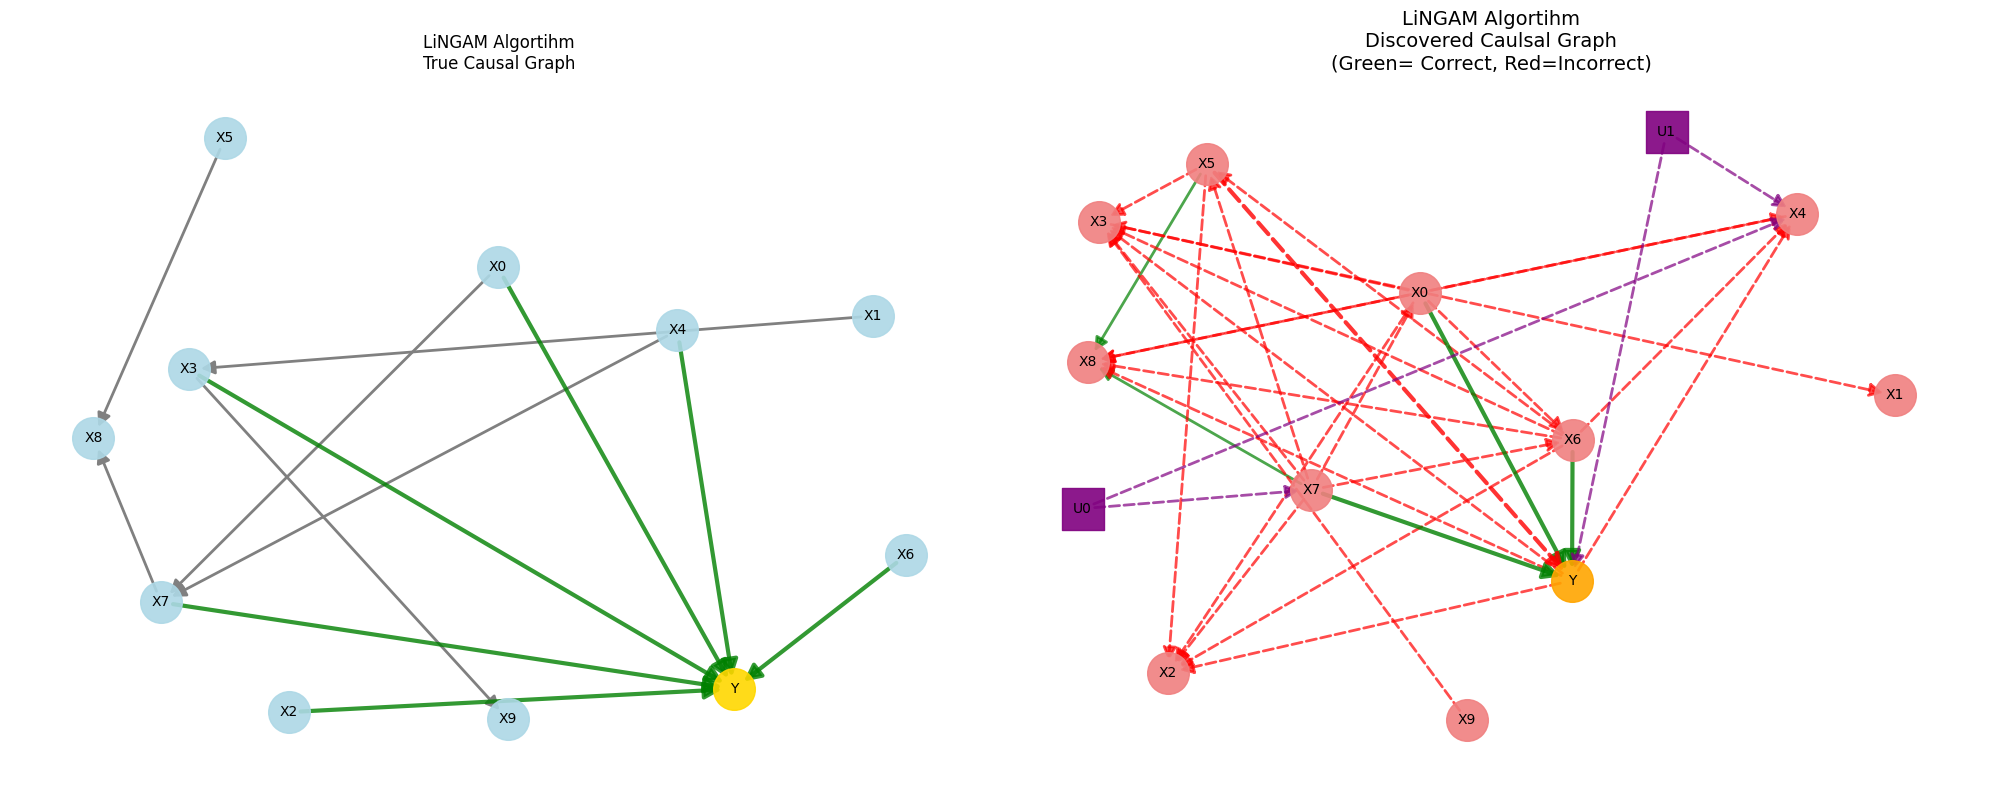

In [7]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [8]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 5,
 'false_positives': 25,
 'false_negatives': 7,
 'true_negatives': 84,
 'precision': 0.16666666666666666,
 'recall': 0.4166666666666667,
 'f1_score': 0.23809523809523808,
 'structural_hamming_distance': 32,
 'n_true_edges': 12,
 'n_discovered_edges': 30,
 'n_true_confounders': 0,
 'n_discovered_confounders': 2}

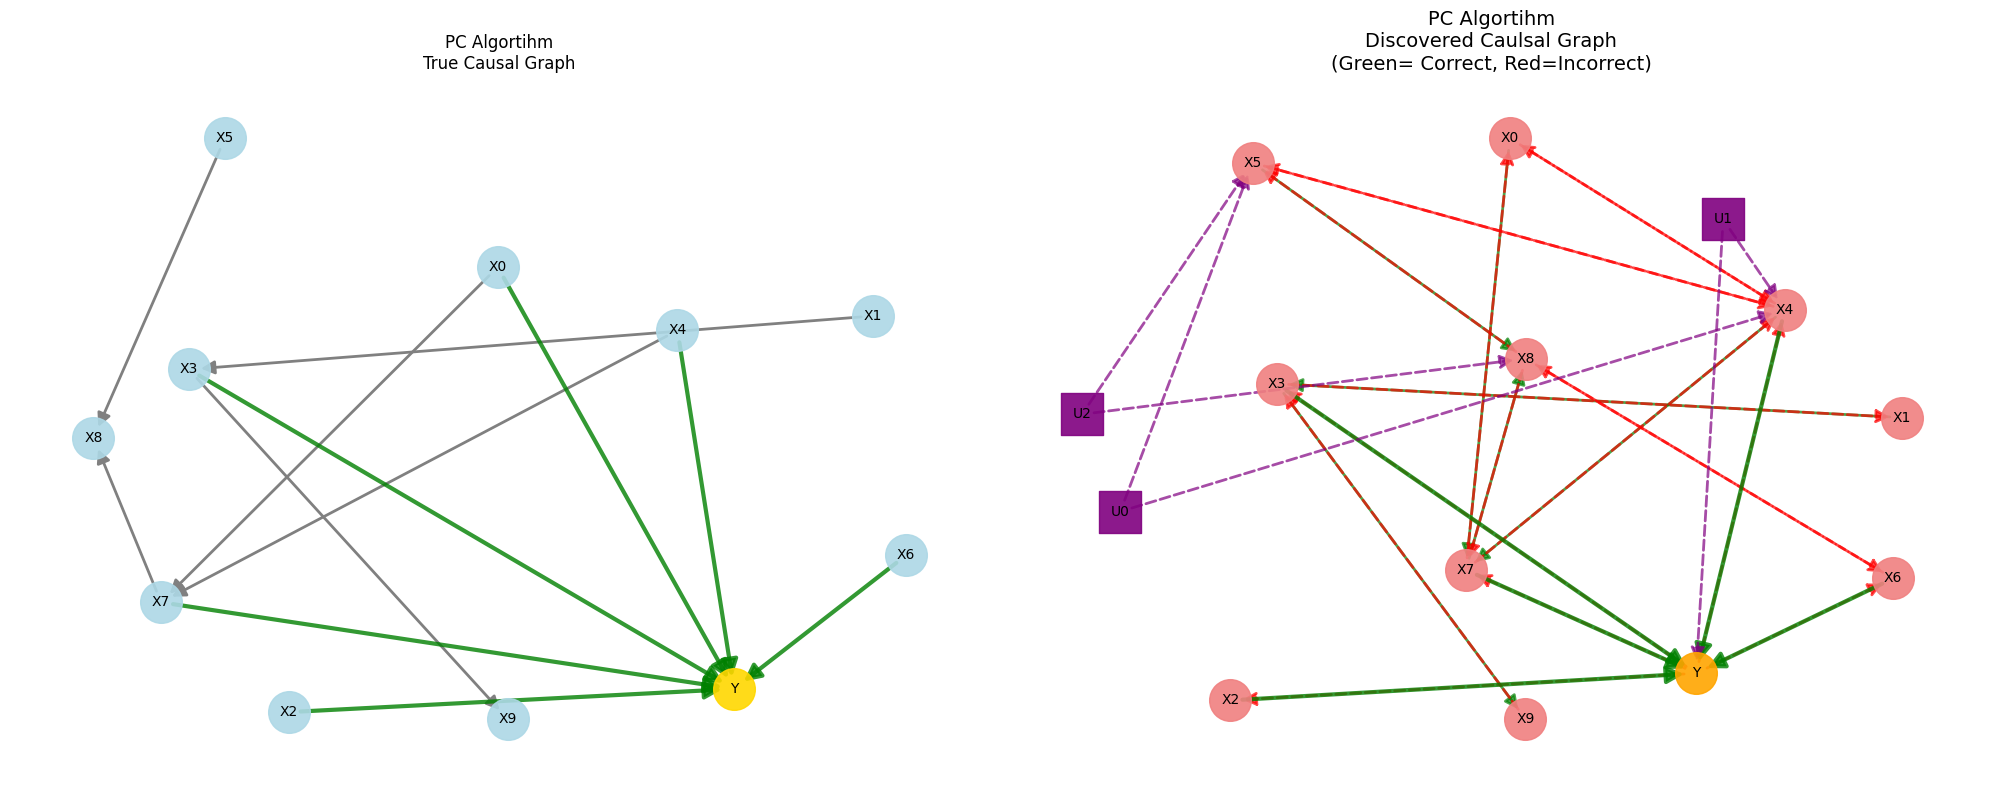

In [9]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [10]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 11,
 'false_positives': 17,
 'false_negatives': 1,
 'true_negatives': 92,
 'precision': 0.39285714285714285,
 'recall': 0.9166666666666666,
 'f1_score': 0.55,
 'structural_hamming_distance': 18,
 'n_true_edges': 12,
 'n_discovered_edges': 28,
 'n_true_confounders': 0,
 'n_discovered_confounders': 3}

# Model building step

In [11]:
no_confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.613645  0.493200  0.924436  0.376561
nn    0.516796  0.418774  0.946406  0.267078


In [12]:
lgbm_model= no_confounder_linear_model["models"]["lgbm"]
nn_model = no_confounder_linear_model["models"]["nn"]

In [13]:
lgbm_model.save(f"../models/{file_path_no_confounders}_lgbm")
nn_model.save(f"../models/{file_path_no_confounders}_nn")

LightGBM model saved to ../models/linear_no_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/linear_no_conf_low_conectivity_6_parents_10_feats_nn.pkl


In [14]:
# lgbm_loaded = LGBMRegressor.load(f"../models/{file_path_no_confounders}_lgbm")
# nn_loaded = NeuralNetRegressor.load(f"../models/{file_path_no_confounders}_nn")

Confounders present

In [15]:
file_path_confounders =f"linear_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [16]:

gen_linear_with_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_linear_with_conf.generate_linear_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_confounders}.parquet")

In [17]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 35 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 254.60it/s]


X2 --> X5
X5 --> X8
X9 --> X11
FCI detected 6 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 732.12it/s]


PC discovered 32 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 407.83it/s]


X5 --> X8
X6 --> X11
X9 --> X11
FCI detected 8 potential confounders pairs


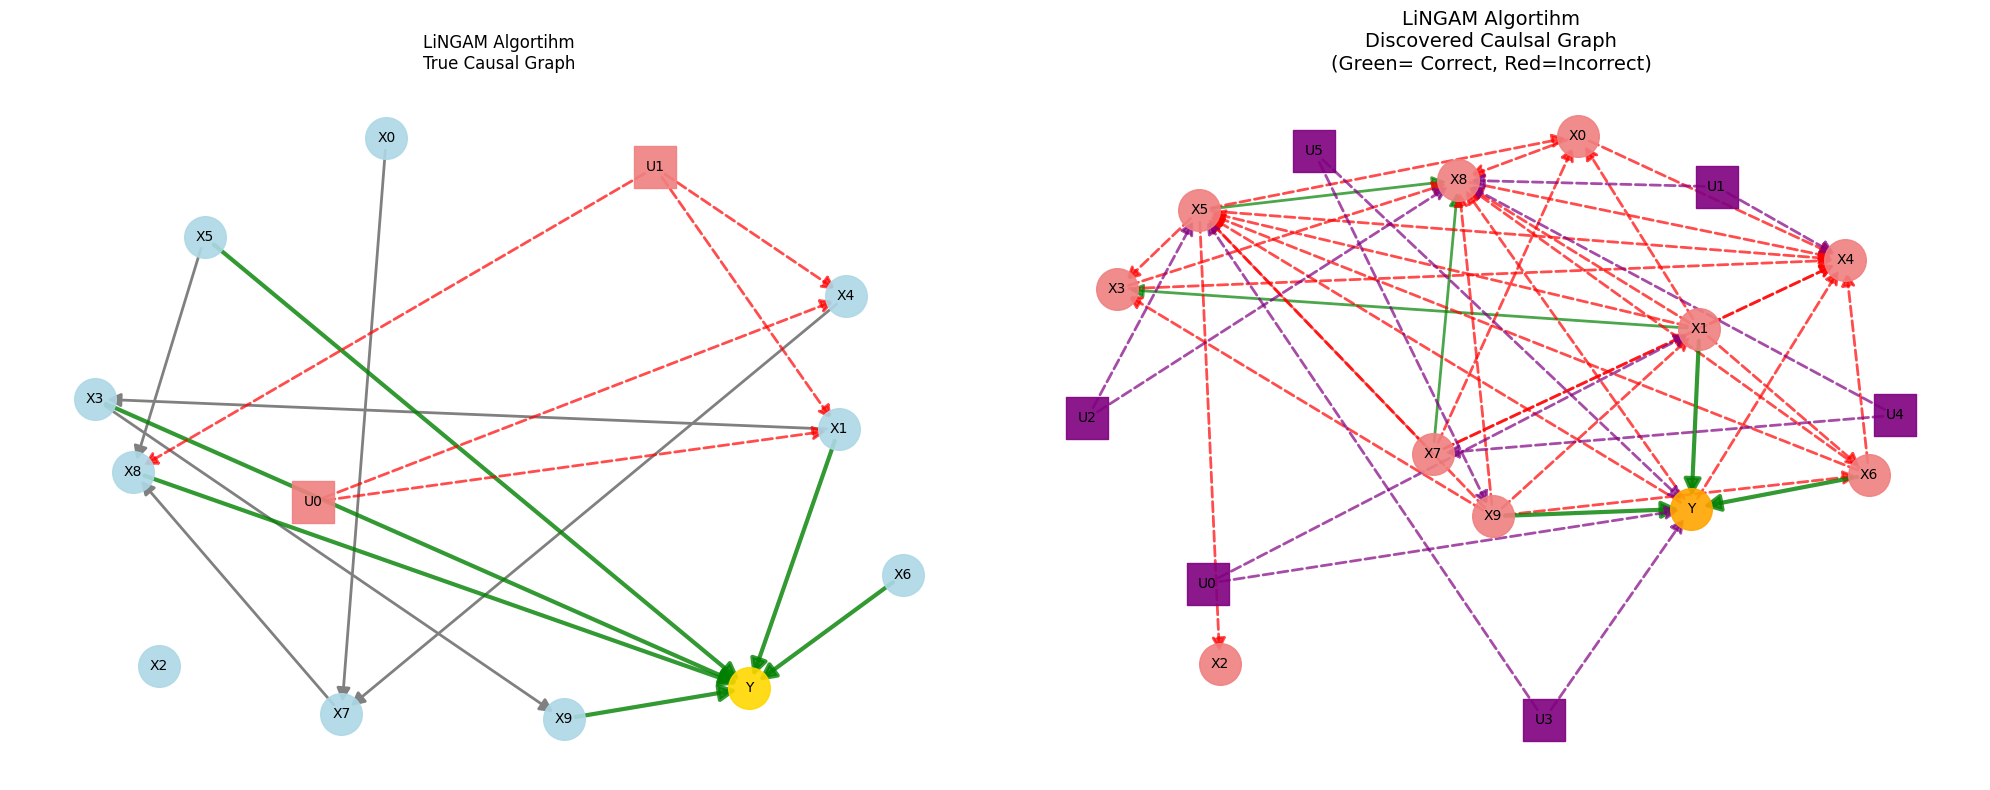

In [18]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_with_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [19]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 6,
 'false_positives': 29,
 'false_negatives': 6,
 'true_negatives': 80,
 'precision': 0.17142857142857143,
 'recall': 0.5,
 'f1_score': 0.2553191489361702,
 'structural_hamming_distance': 35,
 'n_true_edges': 12,
 'n_discovered_edges': 35,
 'n_true_confounders': 2,
 'n_discovered_confounders': 6}

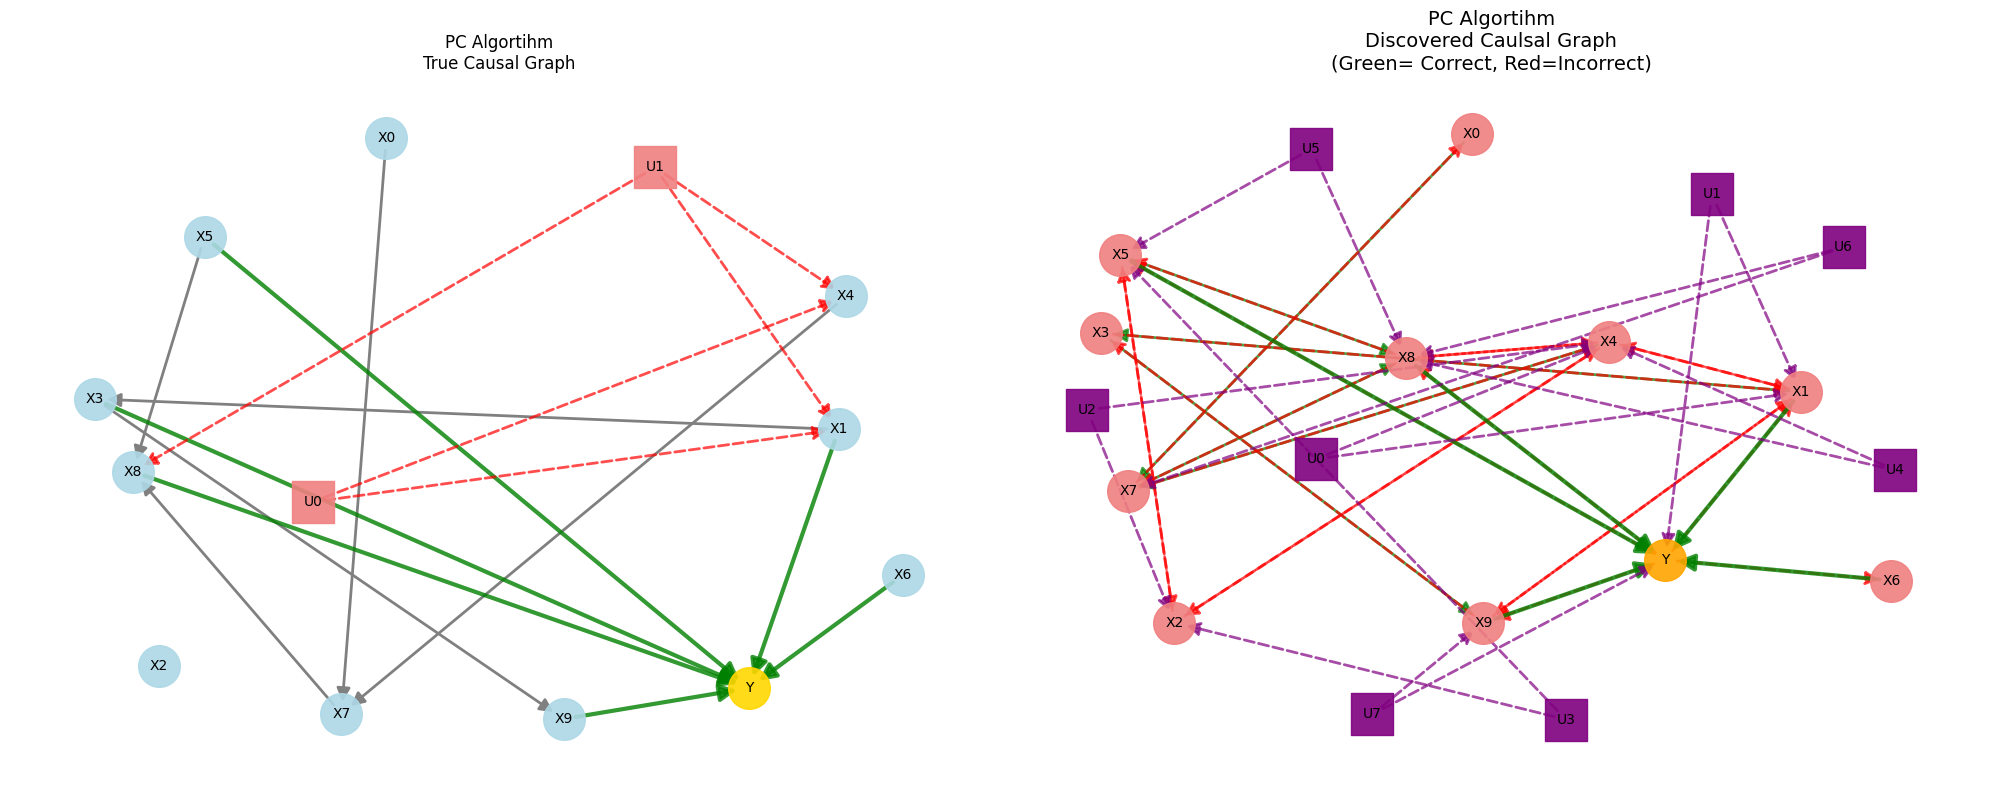

In [20]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_linear_with_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [21]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 11,
 'false_positives': 21,
 'false_negatives': 1,
 'true_negatives': 88,
 'precision': 0.34375,
 'recall': 0.9166666666666666,
 'f1_score': 0.5,
 'structural_hamming_distance': 22,
 'n_true_edges': 12,
 'n_discovered_edges': 32,
 'n_true_confounders': 2,
 'n_discovered_confounders': 8}

# Model building step

In [22]:
confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.677387  0.527791  0.931648  0.458853
nn    0.521153  0.423489  0.959542  0.271600


In [23]:
lgbm_model= confounder_linear_model["models"]["lgbm"]
nn_model = confounder_linear_model["models"]["nn"]

In [24]:
lgbm_model.save(f"../models/{file_path_confounders}_lgbm")
nn_model.save(f"../models/{file_path_confounders}_nn")

LightGBM model saved to ../models/linear_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/linear_conf_low_conectivity_6_parents_10_feats_nn.pkl


# Non-linear data

No confounders present

In [25]:
file_path_no_confounders = f"no_linear_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [26]:
gen_no_linear_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_no_linear_no_conf.generate_nonlinear_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_no_confounders}.parquet")

In [27]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 0 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 192.92it/s]


FCI detected 0 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=9, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 201.59it/s]


PC discovered 110 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 86.74it/s]


FCI detected 0 potential confounders pairs


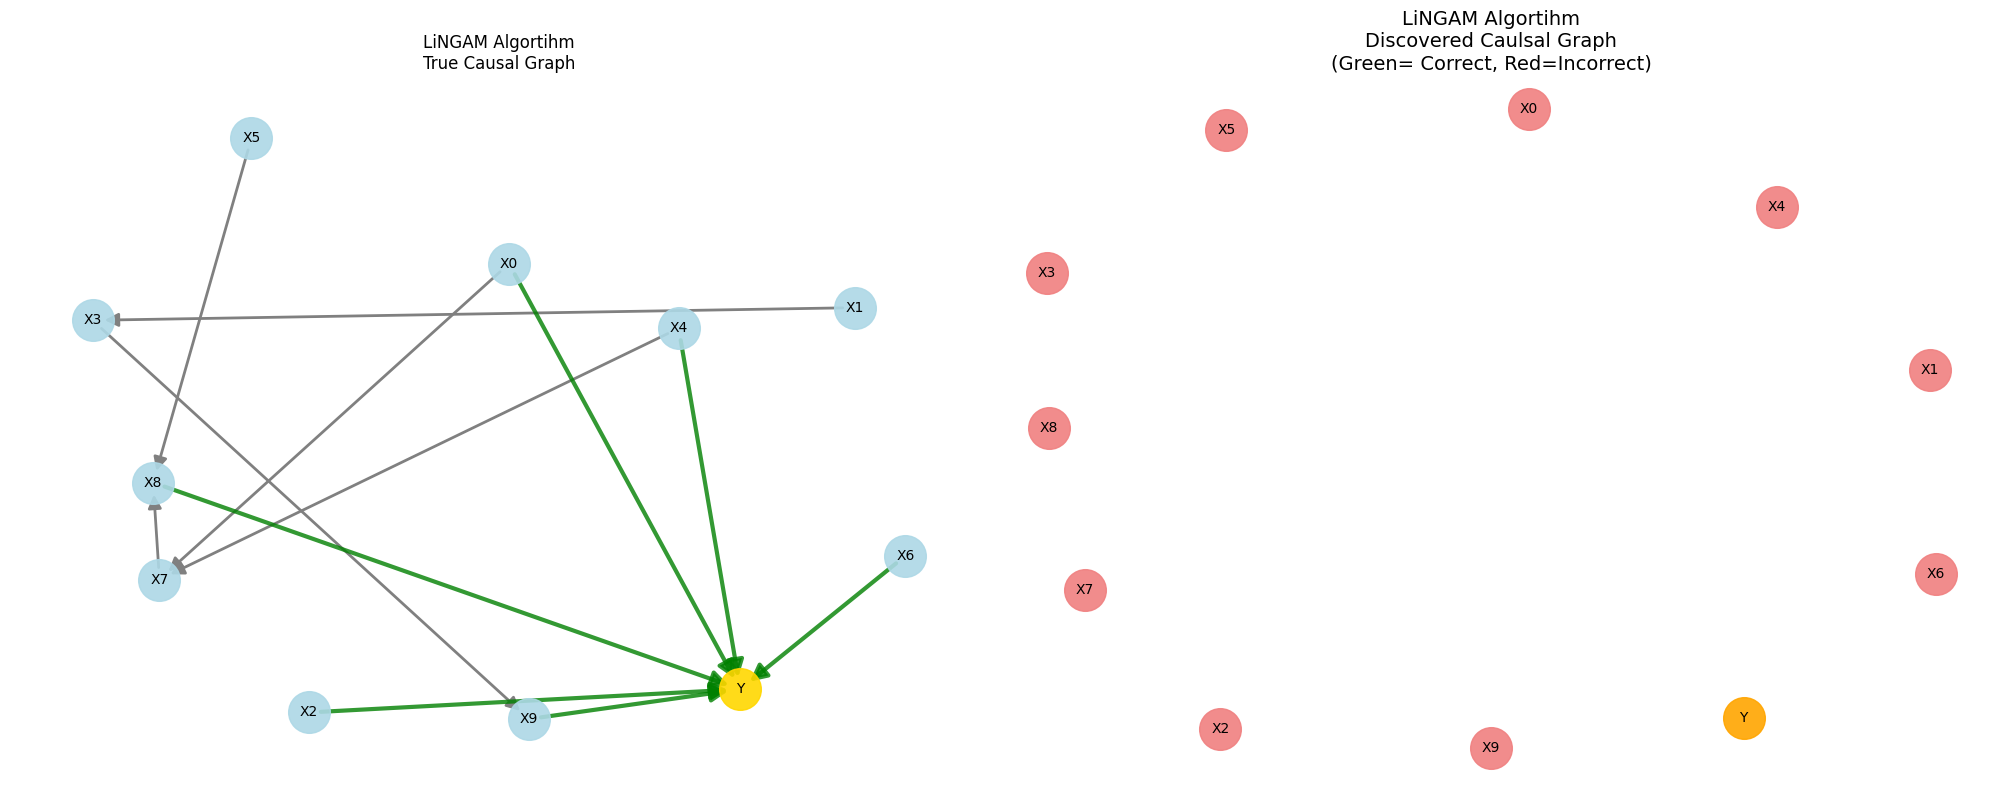

In [28]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [29]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 0,
 'false_positives': 0,
 'false_negatives': 12,
 'true_negatives': 109,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'structural_hamming_distance': 12,
 'n_true_edges': 12,
 'n_discovered_edges': 0,
 'n_true_confounders': 0,
 'n_discovered_confounders': 0}

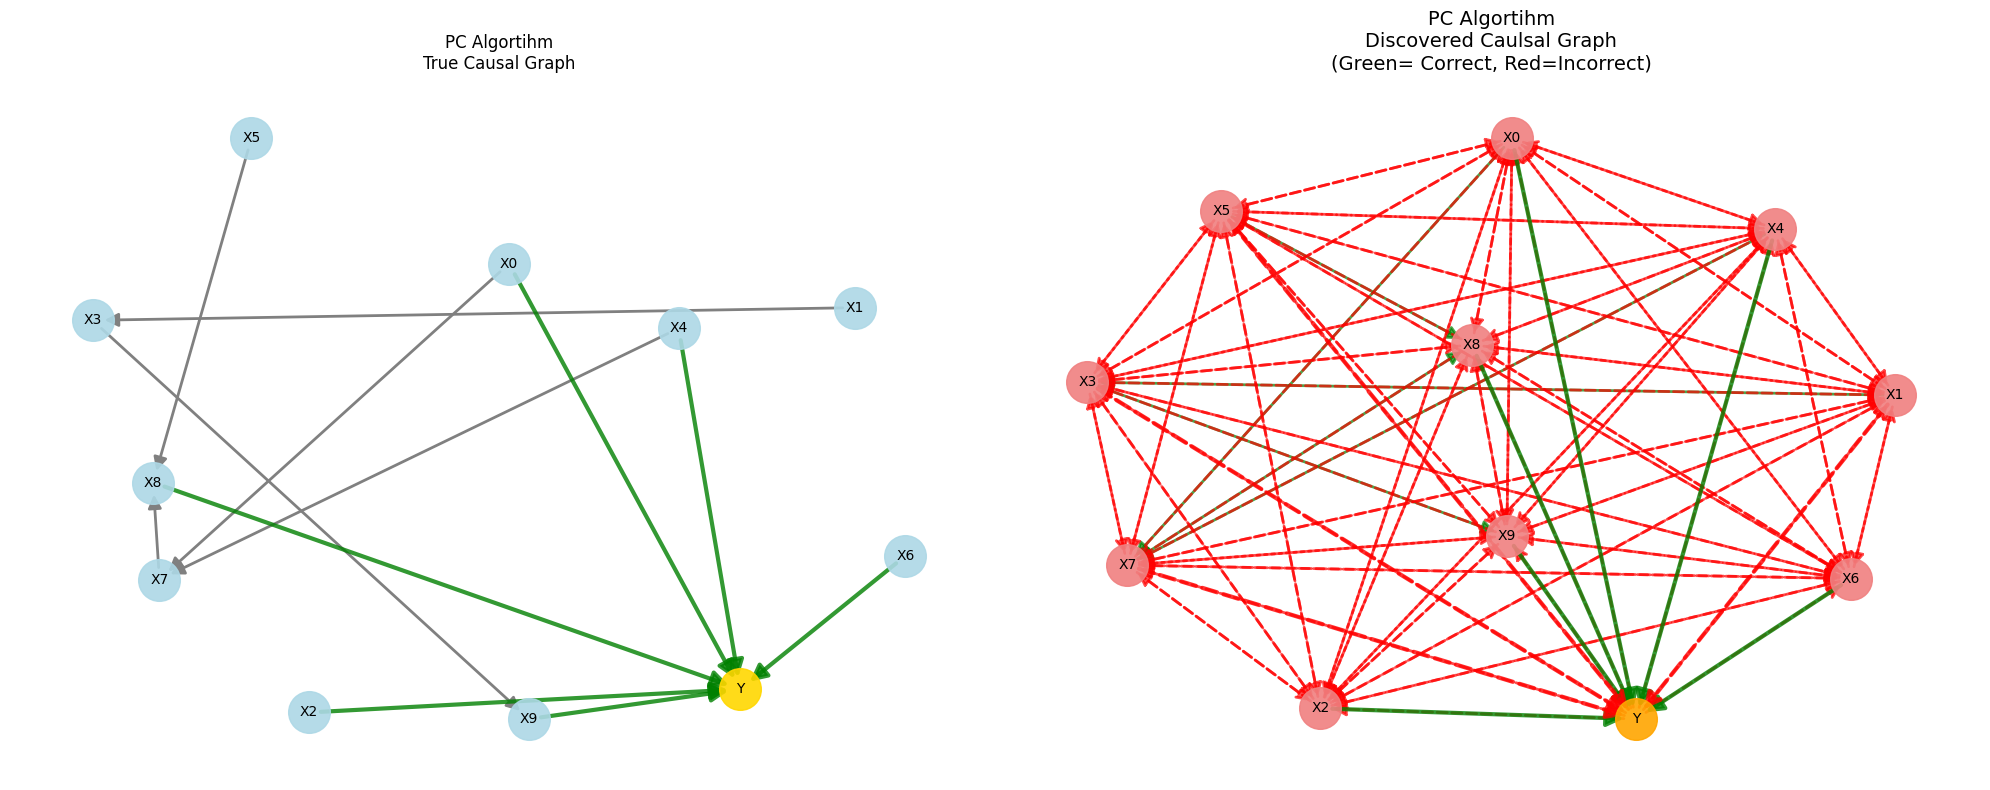

In [30]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [31]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 12,
 'false_positives': 98,
 'false_negatives': 0,
 'true_negatives': 11,
 'precision': 0.10909090909090909,
 'recall': 1.0,
 'f1_score': 0.19672131147540983,
 'structural_hamming_distance': 98,
 'n_true_edges': 12,
 'n_discovered_edges': 110,
 'n_true_confounders': 0,
 'n_discovered_confounders': 0}

# Model building step

In [32]:
no_confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.523193  0.417001 -0.007423  0.273731
nn    0.521281  0.416751 -0.000074  0.271734


In [33]:
lgbm_model= no_confounder_linear_model["models"]["lgbm"]
nn_model = no_confounder_linear_model["models"]["nn"]

In [34]:
lgbm_model.save(f"../models/{file_path_no_confounders}_lgbm")
nn_model.save(f"../models/{file_path_no_confounders}_nn")

LightGBM model saved to ../models/no_linear_no_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/no_linear_no_conf_low_conectivity_6_parents_10_feats_nn.pkl


Confounders present

In [35]:
file_path_confounders = f"no_linear_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [36]:
gen_no_linear_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf = gen_no_linear_conf.generate_nonlinear_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    y_parents_ratio=parents_rate)
data.to_parquet(f"../data/{file_path_confounders}.parquet")

In [37]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 7 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 231.08it/s]


FCI detected 2 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 632.28it/s]


PC discovered 38 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 394.02it/s]


X1 --> X5
X8 --> X11
FCI detected 15 potential confounders pairs


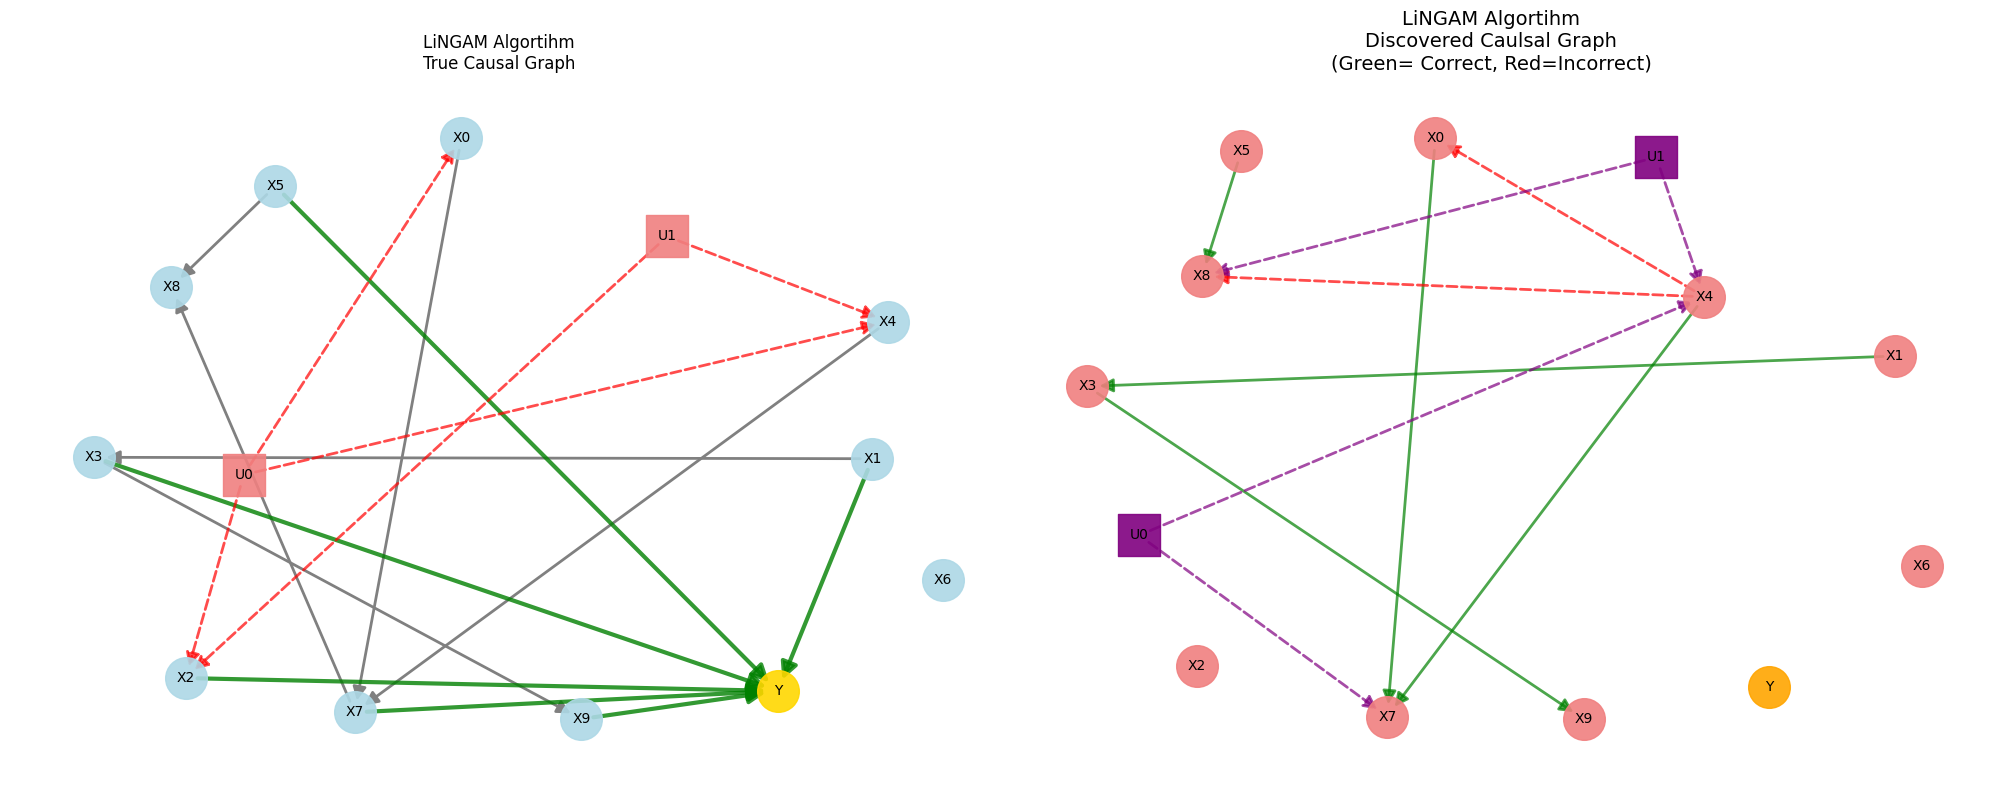

In [38]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [39]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 5,
 'false_positives': 2,
 'false_negatives': 7,
 'true_negatives': 107,
 'precision': 0.7142857142857143,
 'recall': 0.4166666666666667,
 'f1_score': 0.5263157894736842,
 'structural_hamming_distance': 9,
 'n_true_edges': 12,
 'n_discovered_edges': 7,
 'n_true_confounders': 2,
 'n_discovered_confounders': 2}

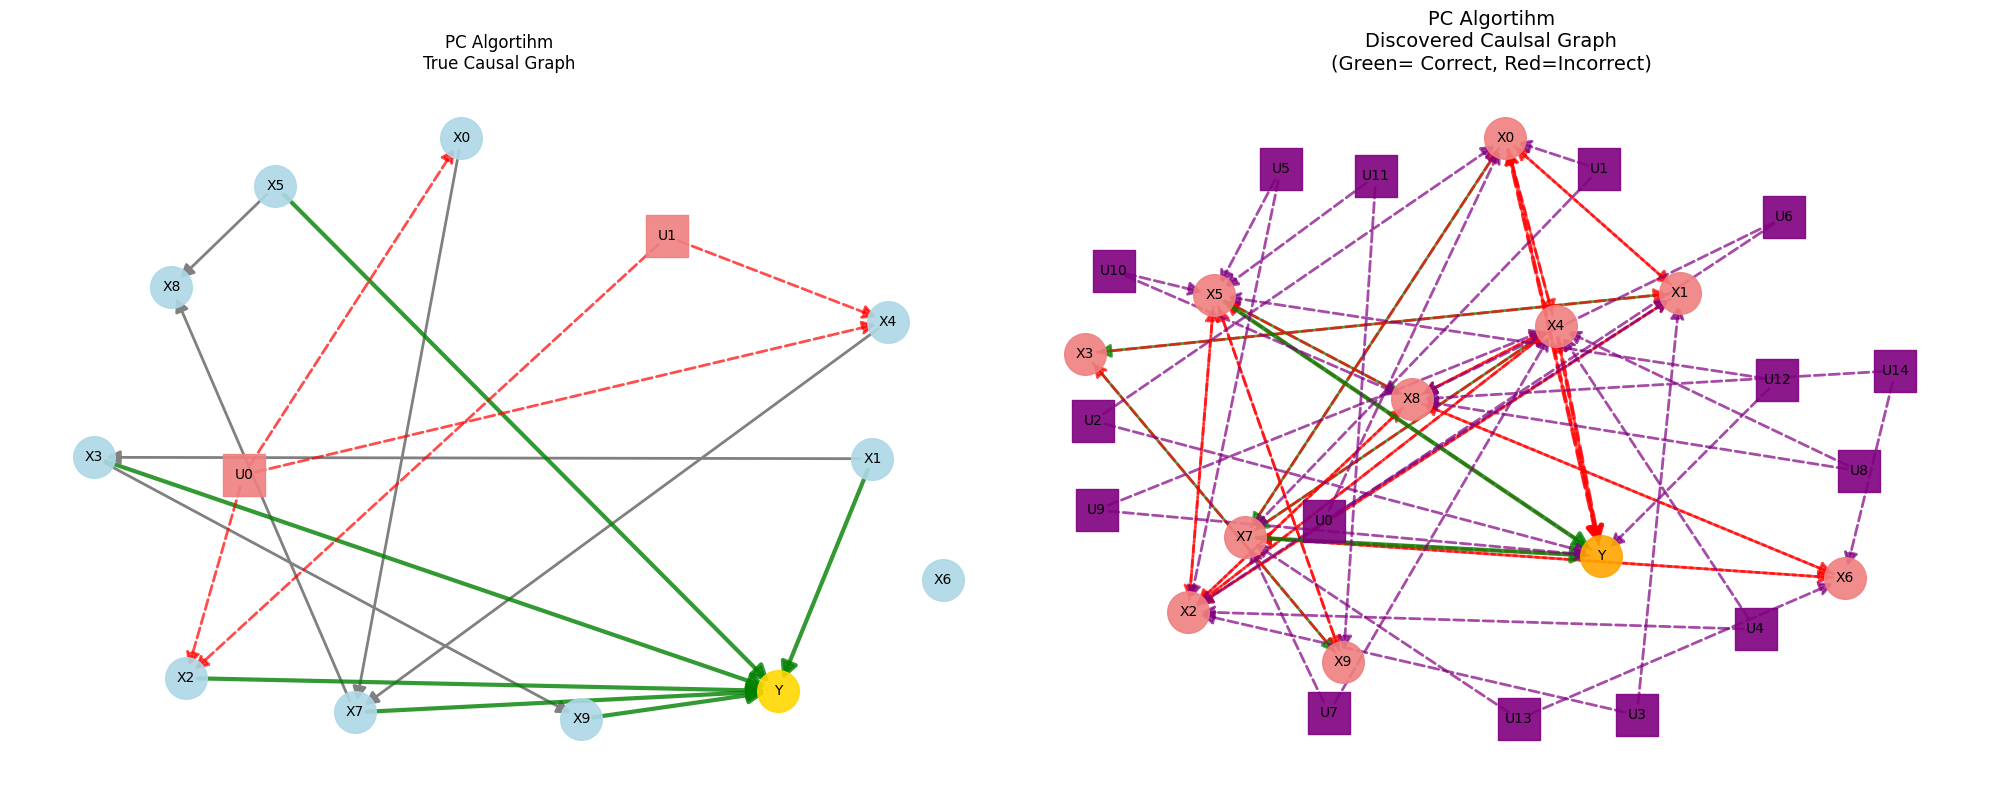

In [40]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_no_linear_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [41]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 7,
 'false_positives': 31,
 'false_negatives': 5,
 'true_negatives': 78,
 'precision': 0.18421052631578946,
 'recall': 0.5833333333333334,
 'f1_score': 0.27999999999999997,
 'structural_hamming_distance': 36,
 'n_true_edges': 12,
 'n_discovered_edges': 38,
 'n_true_confounders': 2,
 'n_discovered_confounders': 15}

# Model building step

In [42]:
confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'hidden_dim_2', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
         val_rmse      val_mae    val_r2       val_mse
lgbm  8332.737304  1021.754504  0.396477  6.943451e+07
nn    9876.925440  1731.995551  0.152066  9.755366e+07


In [43]:
lgbm_model= confounder_linear_model["models"]["lgbm"]
nn_model = confounder_linear_model["models"]["nn"]

In [44]:
lgbm_model.save(f"../models/{file_path_confounders}_lgbm")
nn_model.save(f"../models/{file_path_confounders}_nn")

LightGBM model saved to ../models/no_linear_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/no_linear_conf_low_conectivity_6_parents_10_feats_nn.pkl


# Mixed relationships

In [45]:
file_path_no_confounders = f"mixed_no_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

no confounders

In [46]:
gen_mixed_no_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf, edge_types  = gen_mixed_no_conf.generate_mixed_system(n_samples=sample,
                                                    with_confounders=False,
                                                    noise_std=0.5,
                                                    linear_ratio=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_no_confounders}.parquet")

In [47]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 16 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 374.11it/s]


FCI detected 1 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=7, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 542.79it/s]


PC discovered 50 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 268.00it/s]


FCI detected 22 potential confounders pairs


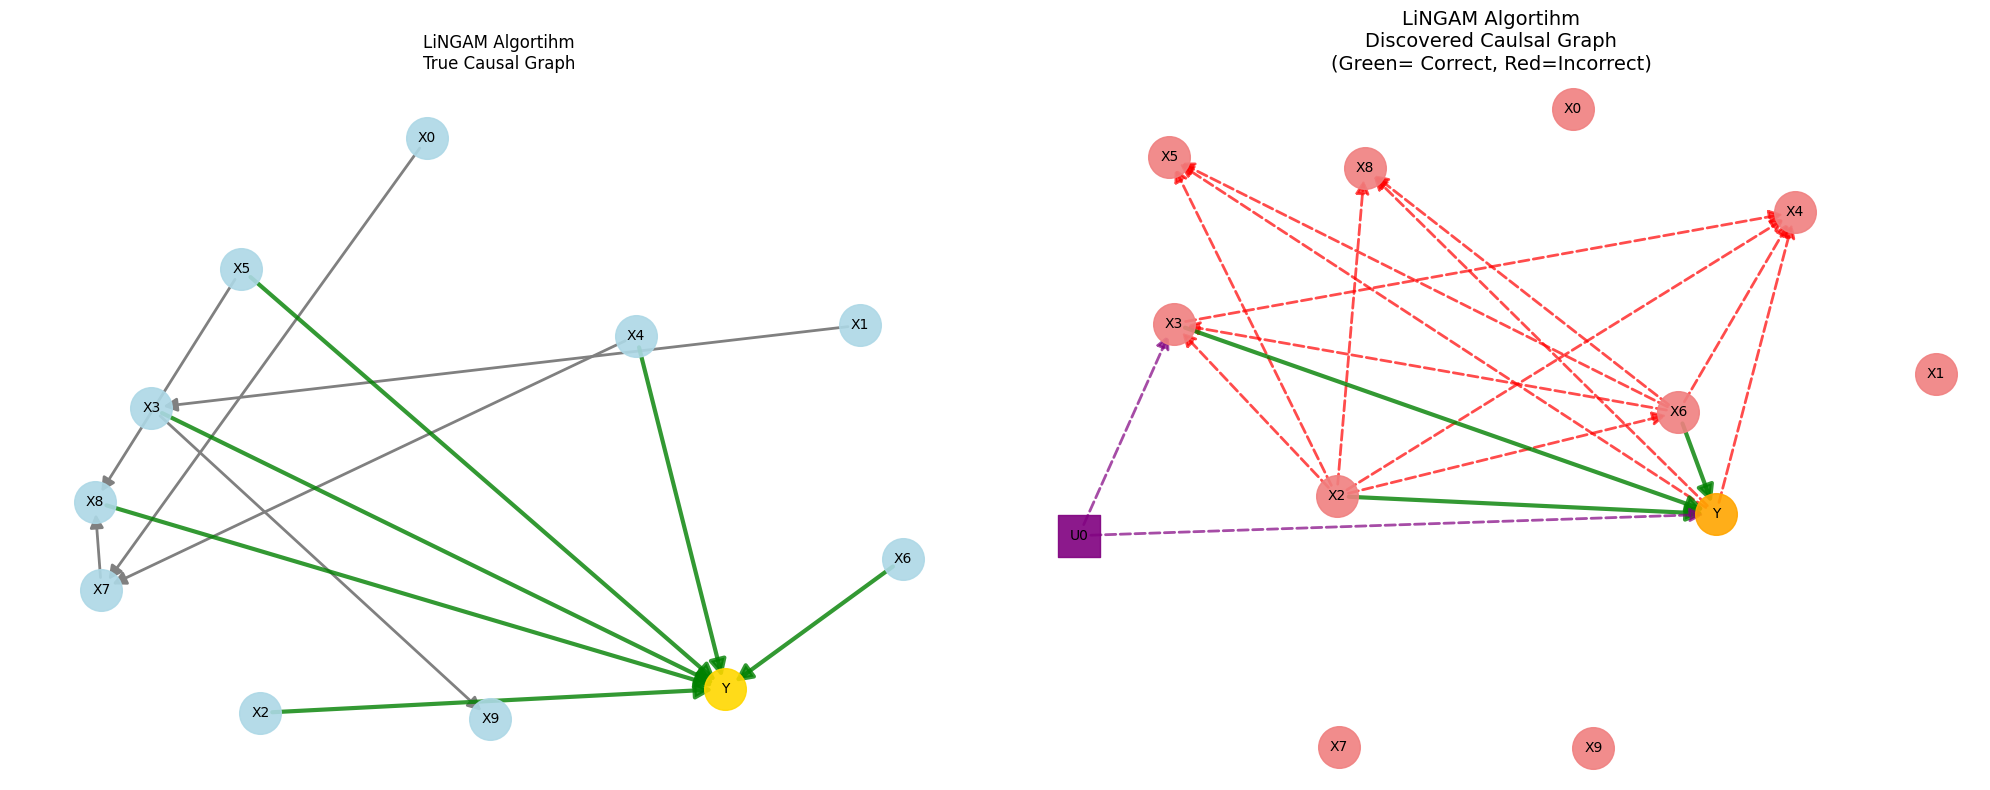

In [48]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [49]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 3,
 'false_positives': 13,
 'false_negatives': 9,
 'true_negatives': 96,
 'precision': 0.1875,
 'recall': 0.25,
 'f1_score': 0.21428571428571427,
 'structural_hamming_distance': 22,
 'n_true_edges': 12,
 'n_discovered_edges': 16,
 'n_true_confounders': 0,
 'n_discovered_confounders': 1}

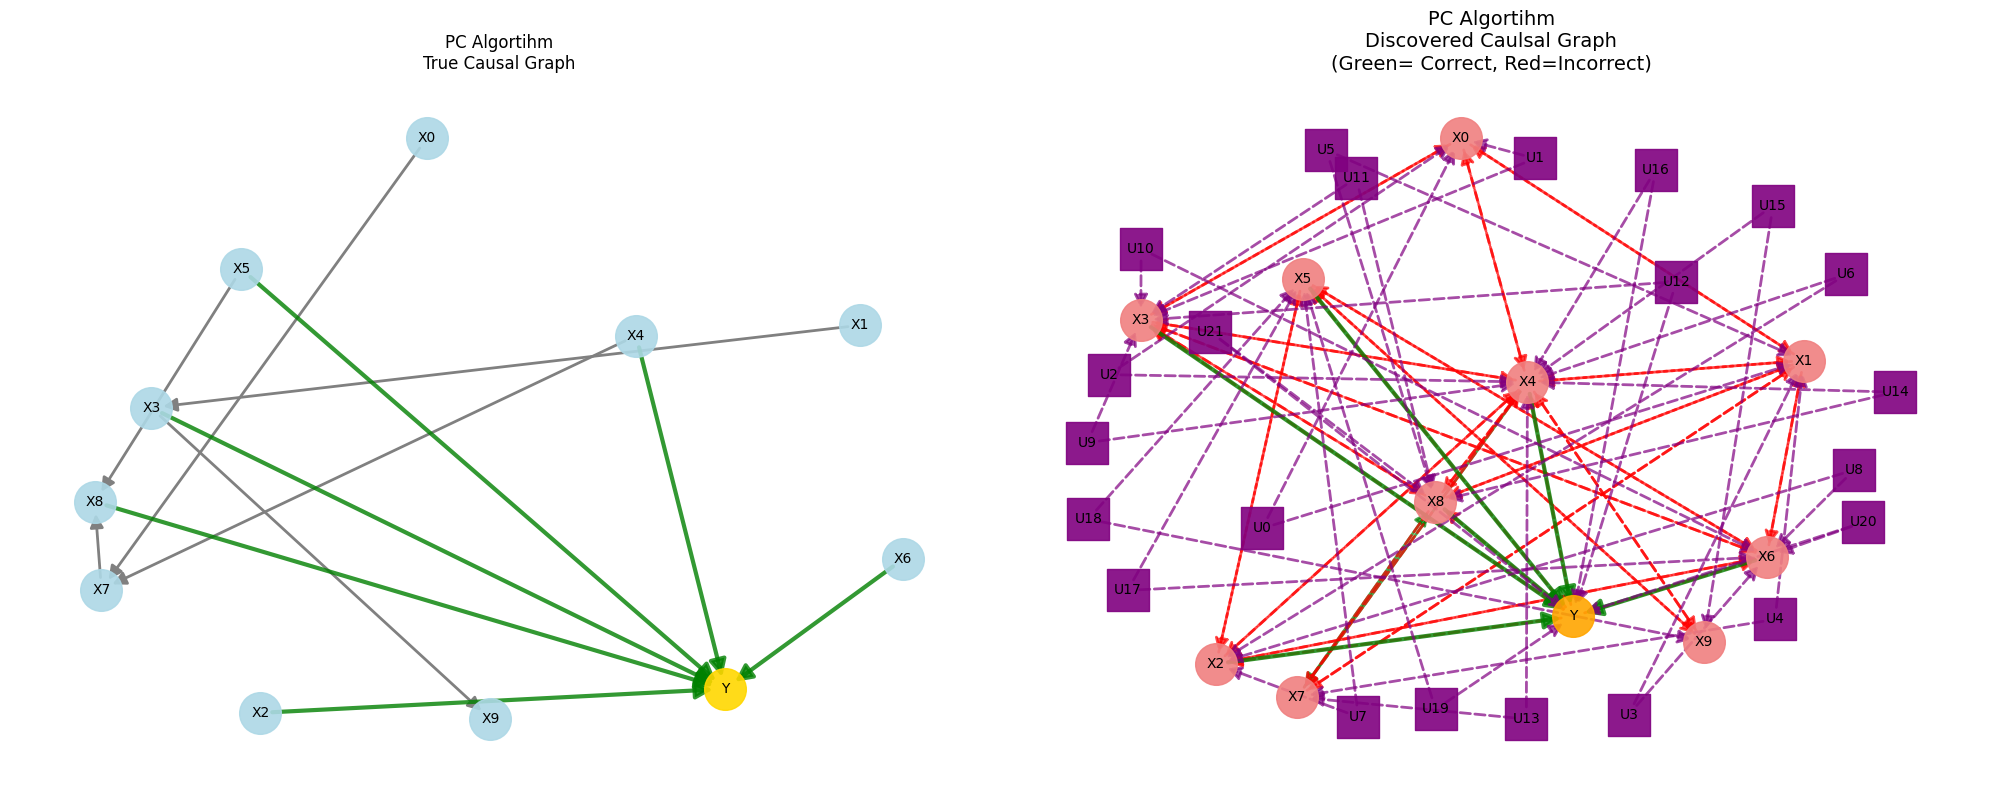

In [50]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_no_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [51]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 8,
 'false_positives': 42,
 'false_negatives': 4,
 'true_negatives': 67,
 'precision': 0.16,
 'recall': 0.6666666666666666,
 'f1_score': 0.25806451612903225,
 'structural_hamming_distance': 46,
 'n_true_edges': 12,
 'n_discovered_edges': 50,
 'n_true_confounders': 0,
 'n_discovered_confounders': 22}

# Model building step

In [52]:
no_confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
      val_rmse   val_mae    val_r2   val_mse
lgbm  0.543497  0.432663  0.752634  0.295389
nn    0.506927  0.397058  0.784803  0.256975


In [53]:
lgbm_model= no_confounder_linear_model["models"]["lgbm"]
nn_model = no_confounder_linear_model["models"]["nn"]

In [54]:
lgbm_model.save(f"../models/{file_path_no_confounders}_lgbm")
nn_model.save(f"../models/{file_path_no_confounders}_nn")

LightGBM model saved to ../models/mixed_no_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/mixed_no_conf_low_conectivity_6_parents_10_feats_nn.pkl


Confounders present

In [55]:
file_path_confounders = f"mixed_conf_low_conectivity_{int(feats*parents_rate)}_parents_{feats}_feats"

In [56]:
gen_mixed_conf=SyntheticCausalSystem(n_features=feats,
                                random_state=42,
                                min_num_connected_edges=2,
                                edge_probability=0.1)
data, adj, conf, edge_types  = gen_mixed_conf.generate_mixed_system(n_samples=sample,
                                                    with_confounders=True,
                                                    noise_std=0.5,
                                                    linear_ratio=0.5,
                                                    y_parents_ratio=parents_rate)

data.to_parquet(f"../data/{file_path_confounders}.parquet")

In [57]:
lingam_fci = LiNGAMWithFCI(alpha=0.05,indep_test="fisherz")
pci_fci = PCWithFCI(alpha=0.5, indep_test="fisherz")
results_lingam = lingam_fci.get_causal_relationships(data)
results_pc = pci_fci.get_causal_relationships(data)

Running LiNGAM algorithm for causal structure discovery...
LiNGAM discovered 7 edges
Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 430.82it/s]


FCI detected 3 potential confounders pairs
 Running PC algorithm for causal structure discovery...


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 544.95it/s]


PC discovered 38 edges
 Running FCI algorithm for confounder detection...


Depth=0, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 391.17it/s]


X5 --> X8
X5 --> X9
X8 --> X7
FCI detected 12 potential confounders pairs


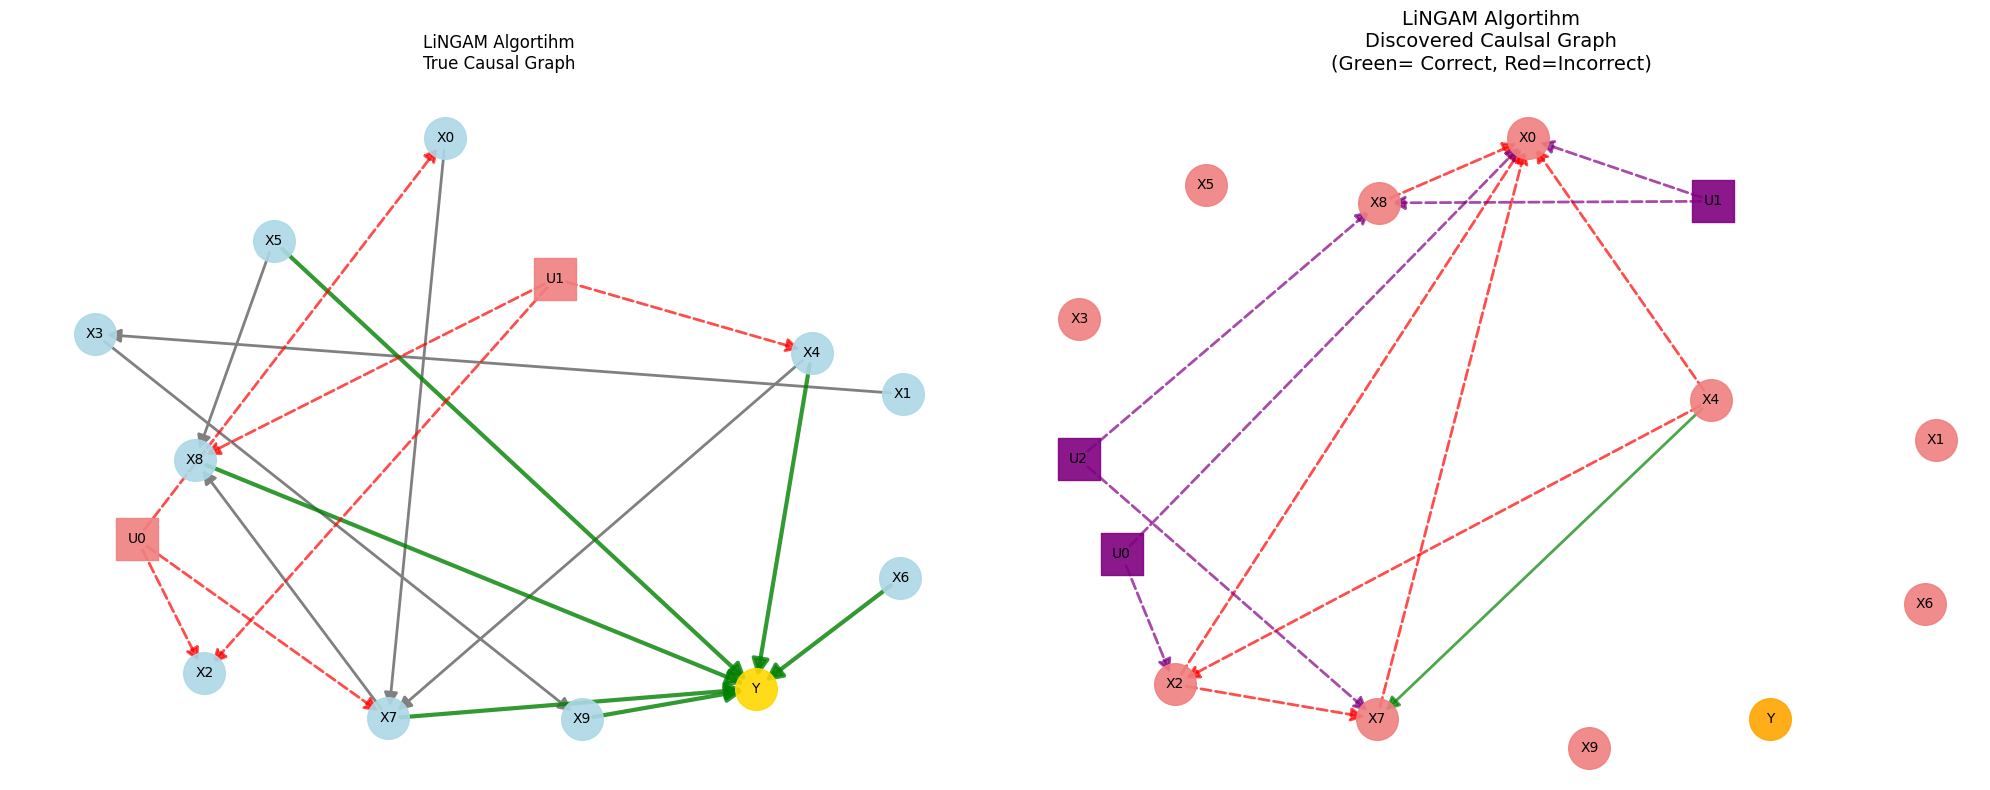

In [58]:
fig_lingam=visualize_comparison(true_adj=adj,
                     discovered_adj=results_lingam["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_lingam["confounders"],
                     title_preix='LiNGAM Algortihm'
                     )

In [59]:
compare_with_ground_truth( discovered_adj=results_lingam["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_lingam["confounders"],
                              true_confounders=conf)

{'true_positives': 1,
 'false_positives': 6,
 'false_negatives': 11,
 'true_negatives': 103,
 'precision': 0.14285714285714285,
 'recall': 0.08333333333333333,
 'f1_score': 0.10526315789473685,
 'structural_hamming_distance': 17,
 'n_true_edges': 12,
 'n_discovered_edges': 7,
 'n_true_confounders': 2,
 'n_discovered_confounders': 3}

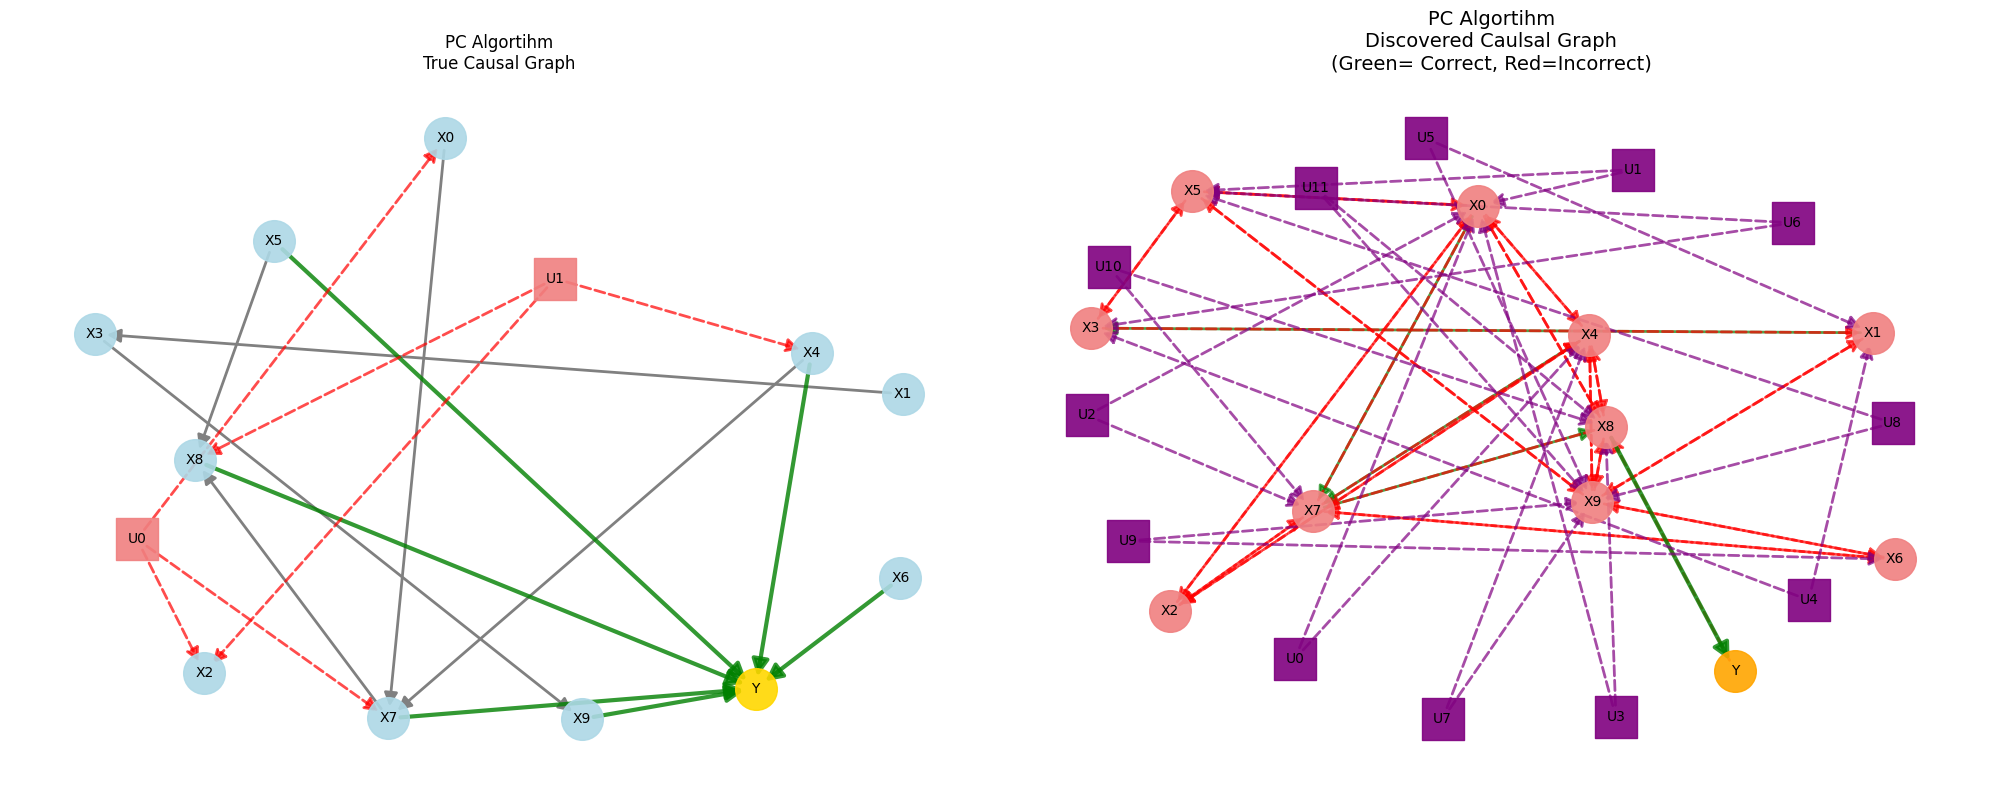

In [60]:
fig_pc=visualize_comparison(true_adj=adj,
                     discovered_adj=results_pc["adjacency_matrix"],
                     features_names=data.columns.tolist(),
                     y_parent_indices=gen_mixed_conf.y_parent_indices,
                     true_confounders=conf,
                     discovered_confounders=results_pc["confounders"],
                     title_preix='PC Algortihm'
                     )

In [61]:
compare_with_ground_truth( discovered_adj=results_pc["adjacency_matrix"],
                              true_adj=adj,
                              discovered_confounders=results_pc["confounders"],
                              true_confounders=conf)

{'true_positives': 5,
 'false_positives': 33,
 'false_negatives': 7,
 'true_negatives': 76,
 'precision': 0.13157894736842105,
 'recall': 0.4166666666666667,
 'f1_score': 0.19999999999999998,
 'structural_hamming_distance': 40,
 'n_true_edges': 12,
 'n_discovered_edges': 38,
 'n_true_confounders': 2,
 'n_discovered_confounders': 12}

# Model building step

In [62]:
confounder_linear_model = train_predictive_models(
    data,
    y_column='Y',
    models=["lgbm","nn"],
    features_selection=True,
    optimize=True,
    random_state=42
)

Training models to predict Y
Features: 10, Samples: 1000
[1/2] Training LightGBM Regressor
----------------------------------------------------------------------
Optimizing LightGBM hyperparameters (50 trials)...
Training LightGBM model...
[1/2] Training Neural Network Regressor
----------------------------------------------------------------------
Optimizing Neural Network hyperparameters (50 trials)...
dict_keys(['n_layers', 'hidden_dim_0', 'hidden_dim_1', 'hidden_dim_2', 'alpha', 'learning_rate_init', 'batch_size', 'activation'])
Training Neural Network model...
           val_rmse       val_mae    val_r2       val_mse
lgbm  250562.670716  28633.745713  0.307740  6.278165e+10
nn    124370.022869  11324.538737  0.829444  1.546790e+10


In [63]:
lgbm_model= confounder_linear_model["models"]["lgbm"]
nn_model = confounder_linear_model["models"]["nn"]

In [64]:
lgbm_model.save(f"../models/{file_path_confounders}_lgbm")
nn_model.save(f"../models/{file_path_confounders}_nn")

LightGBM model saved to ../models/mixed_conf_low_conectivity_6_parents_10_feats_lgbm.pkl
Neural Network model saved to ../models/mixed_conf_low_conectivity_6_parents_10_feats_nn.pkl
